In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
df_T_convo_topic = pd.read_csv("T/data_topics/final_topic_convo_T.csv")

In [10]:
bert_dist_T = (
    df_T_convo_topic.groupby(["topic_label", "bert_majority_label"]).size().unstack()
)

compound_dist_T = (
    df_T_convo_topic.groupby(["topic_label", "compound_utt_label"]).size().unstack()
)

In [11]:
bert_pct_T = bert_dist_T.div(bert_dist_T.sum(axis=1), axis=0)
compound_pct_T = compound_dist_T.div(compound_dist_T.sum(axis=1), axis=0)

In [17]:
summary_T = pd.concat(
    {
        # "bert_counts": bert_dist_E,
        "bert_pct": round(bert_pct_T * 100, 2),
        # "compound_counts": compound_dist_E,
        # "compound_pct": round(compound_pct_T * 100, 2)
    },
    axis=1
)

In [18]:
summary_T

bert_pct                 
bert_majority_label Negative Neutral Positive
topic_label                                  
Customization          16.93   67.00    16.07
Gameplay               25.90   57.46    16.64
Hardware               30.10   54.52    15.38
Other                  34.55   50.29    15.16
Problems               63.33   29.42     7.25
Social                 16.29   49.21    34.50

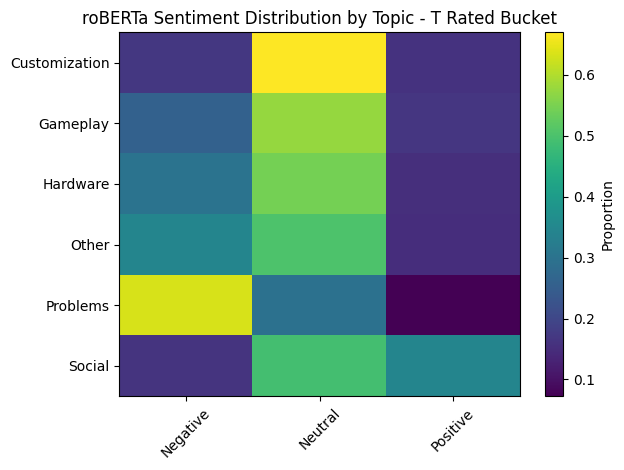

In [14]:
plt.imshow(bert_pct_T, aspect='auto')

plt.xticks(range(len(bert_pct_T.columns)), bert_pct_T.columns, rotation=45)
plt.yticks(range(len(bert_pct_T.index)), bert_pct_T.index)

plt.title("roBERTa Sentiment Distribution by Topic - T Rated Bucket")
plt.colorbar(label="Proportion")

plt.tight_layout()
plt.show()